## Business Understanding
 ### Background
 A company aiming to delve into purchasing and operating airplanes for commercial and private    enterprises.


 ## Goal
 This analysis aims to determine the aircraft with the lowest operational risk.

 ## Key questions:
 1.1.Which airplane has the least operational risk overall?

 2.What is the effect of weather conditions on airplane operations?
 
 3.Which aircraft make shows the lowest rate of fatal injuries?

### Data understanding

## Data source
This publicly available dataset contains historical aviation accident data. It contains details on aircrafts, weather conditions, injuries recorded in the past among others.

In [566]:
import pandas as pd


In [567]:
df=pd.read_csv('Aviation_Data.csv') # loading the dataset
df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_7244\3318372375.py:1: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Aviation_Data.csv') # loading the dataset


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [568]:
df.shape #to check the number of rows and columns


(90348, 31)

This dataset contains 90348 accident records and 31 variables which include weather conditions,total fatal injuries, total serious injuries, the make and model of the aircraft.

In [569]:
df.columns #checking the column names 

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

The variables are of categorical and numerical nature which makes them suitable for aircraft operational risk analysis. 

In [570]:
df.isna().sum() #checking for missing values

Event.Id                   1459
Investigation.Type            0
Accident.Number            1459
Event.Date                 1459
Location                   1511
Country                    1685
Latitude                  55966
Longitude                 55975
Airport.Code              40216
Airport.Name              37644
Injury.Severity            2459
Aircraft.damage            4653
Aircraft.Category         58061
Registration.Number        2841
Make                       1522
Model                      1551
Amateur.Built              1561
Number.of.Engines          7543
Engine.Type                8555
FAR.Description           58325
Schedule                  77766
Purpose.of.flight          7651
Air.carrier               73700
Total.Fatal.Injuries      12860
Total.Serious.Injuries    13969
Total.Minor.Injuries      13392
Total.Uninjured            7371
Weather.Condition          5951
Broad.phase.of.flight     28624
Report.Status              7843
Publication.Date          16689
dtype: i

In [571]:
df.describe()

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
count,82805.000000,77488.000000,76379.000000,76956.000000,82977.000000
mean,1.146585,0.647855,0.279881,0.357061,5.325440
std,0.446510,5.485960,1.544084,2.235625,27.913634
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000
max,8.000000,349.000000,161.000000,380.000000,699.000000


## Data analysis

In [572]:
my_data= df.copy() # creating a copy of the original dataset
my_data

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90343,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022
90344,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
90345,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
90346,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


This creates a copy of the original dataset so that changes can only alter the copy and not the original dataset.

In [573]:
keywords=['Make','Model','Total','damage','Engine','flight','Weather','Severity'] # filtering out relevant columns using their keywords
relevant_cols=[]
for col in my_data.columns:
    for keyword in keywords:
        if keyword in col:
            relevant_cols.append(col)
            break
relevant_cols

['Injury.Severity',
 'Aircraft.damage',
 'Make',
 'Model',
 'Number.of.Engines',
 'Engine.Type',
 'Purpose.of.flight',
 'Total.Fatal.Injuries',
 'Total.Serious.Injuries',
 'Total.Minor.Injuries',
 'Total.Uninjured',
 'Weather.Condition',
 'Broad.phase.of.flight']

Aircraft operational risk is asssessed through elements such as severity of injuries, extent of aircraft

damage and weather comditions. Filtering out the relevant columns makes the analysis easier. 

A scale of 1-5 is used to create a weighted severity score as follows:

5*Total.Fatal.Injuries

4*Total.Serious.Injuries

3*Total.Minor.Injuries


The higher the weight the more severe the outcome.

In [574]:
my_data['weight_sev_score']= my_data['Total.Fatal.Injuries']*5 + my_data['Total.Serious.Injuries']*4 + my_data['Total.Minor.Injuries']*3 


A new column weight_sev_score was created to show the severity of the outcome

In [575]:
grouped = my_data.groupby(['Make', 'Model']) #grouping all accident records based on the aircraft make and model

risk_by_model = grouped['weight_sev_score'].agg(
    Total_Accidents='count',
    Avg_Severity='mean'
) # to know the number of accidents per aircraft model and their mean severity score

risk_by_model = risk_by_model.sort_values(by='Avg_Severity')# rates the aicraft models according to their mean severity score from the least to the highest
risk_by_model

Total_Accidents  Avg_Severity
Make                   Model                                            
Zeigler                MONI                              1           0.0
ADAMS JOHN R JR        PIEL DIAMANT                      1           0.0
ADRIAN GEORGE W        EUROPA CLASSIC                    1           0.0
Zenair                 ZENITH CH 801                     1           0.0
                       CH 701                            1           0.0
...                                                    ...           ...
Zivko                  Edge 540-T                        0           NaN
Zivko Aeronautics Inc. Edge 540-T                        0           NaN
Zlin                   Z-42M                             0           NaN
Zlin Aviation S.r.o.   Savage                            0           NaN
Zorn                   EAA Sport Bi-Plane                0           NaN

[20136 rows x 2 columns]

Accident records were grouped according to their make and model. The number of accidents and the mean 

severity score per model was calculated. This helped to determine the aircraft model that was the 

safest  based on the mean severity score. 

In [576]:
risk_by_make = (my_data.groupby('Make').agg(Total_Accidents=('weight_sev_score', 'count'), Avg_Severity=('weight_sev_score', 'mean'), Total_Fatalities=('Total.Fatal.Injuries', 'sum')).sort_values('Avg_Severity'))
risk_by_make

,Total_Accidents,Avg_Severity,Total_Fatalities
Make,,,
Xtremeair GMBH,1,0.0,0.0
YAKOVLEV/DAY,1,0.0,0.0
YOUNG DEE C,1,0.0,0.0
Kaminskas,1,0.0,0.0
Kane,1,0.0,0.0
...,...,...,...
Zilz,0,NaN,0.0
Zivko,0,NaN,0.0
Zivko Aeronautics Inc.,0,NaN,1.0


This gave the safest aircraft make based on their mean severity, total fatalities and total accidents of all models

In [577]:
risk_by_make = risk_by_make[risk_by_make['Total_Accidents'] >= 50]# remove all aircraft makes whose accidents<50
risk_by_make

,Total_Accidents,Avg_Severity,Total_Fatalities
Make,,,
GRUMMAN ACFT ENG COR-SCHWEIZER,58,1.206897,1.0
AVIAT AIRCRAFT INC,72,1.305556,7.0
Weatherly,73,1.328767,10.0
Grumman-schweizer,85,1.341176,7.0
Let,86,1.360465,36.0
...,...,...,...
Douglas,217,25.373272,963.0
Lockheed,83,26.421687,307.0
Mcdonnell Douglas,370,27.764865,1270.0


This retained aircraft makes with accidents >=50 to ensure a reliable risk margin is used for analysis

In [578]:
lowest_risk_aircraft = risk_by_make.head(10)# gives the top 10 safest aircraft
lowest_risk_aircraft


,Total_Accidents,Avg_Severity,Total_Fatalities
Make,,,
GRUMMAN ACFT ENG COR-SCHWEIZER,58,1.206897,1.0
AVIAT AIRCRAFT INC,72,1.305556,7.0
Weatherly,73,1.328767,10.0
Grumman-schweizer,85,1.341176,7.0
Let,86,1.360465,36.0
Air Tractor,427,1.540984,84.0
Helio,80,1.725000,17.0
Ayres,158,1.734177,38.0
Hiller,287,1.783972,26.0


At this point, a dataframe showing the top 10 safest aircraft make based on operational risk was created. 

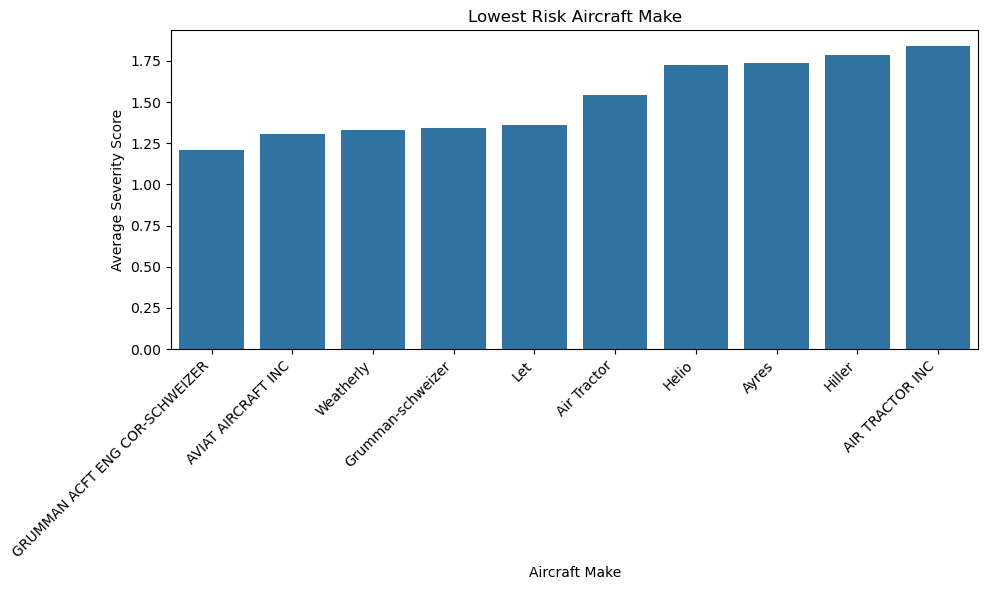

In [579]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = lowest_risk_aircraft.reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x='Make',
    y='Avg_Severity',
    order=plot_data['Make'] #ensures xlabels are below their respective bars
)

plt.title('Lowest Risk Aircraft Make')
plt.xlabel('Aircraft Make')
plt.ylabel('Average Severity Score')

plt.xticks(rotation=45,ha='right') #puts xlabels at a 45 degree angle to prevent them from overlapping
plt.tight_layout()
plt.show()


This barplot represents the relation between the aircraft make and the average severity score showing the 

safest to the least safe aircraft make.



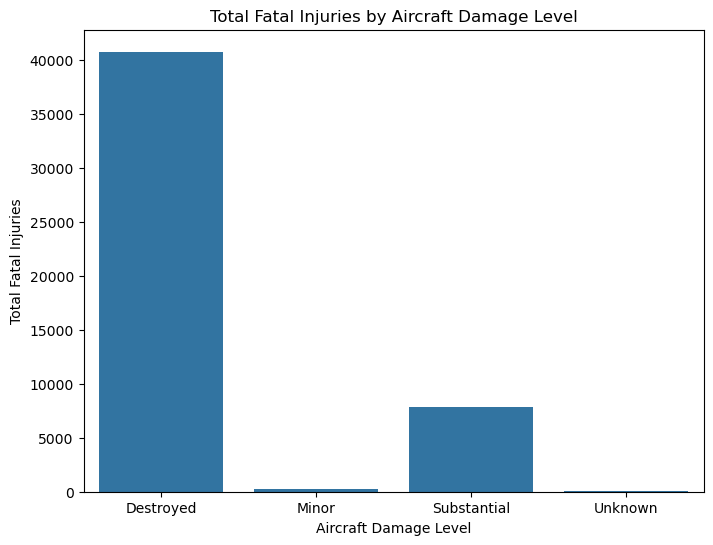

In [580]:
damage_info = (
    my_data
    .groupby('Aircraft.damage')['Total.Fatal.Injuries']
    .sum()
    .reset_index()
)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=damage_info,
    x='Aircraft.damage',
    y='Total.Fatal.Injuries'
)

plt.title('Total Fatal Injuries by Aircraft Damage Level')
plt.xlabel('Aircraft Damage Level')
plt.ylabel('Total Fatal Injuries')


plt.show()


This barplot clearly shows that the level of aircraft damage largely contributes to the number of fatal injuries. 

The greater the aircraft damage the higher the number of fatal injuries

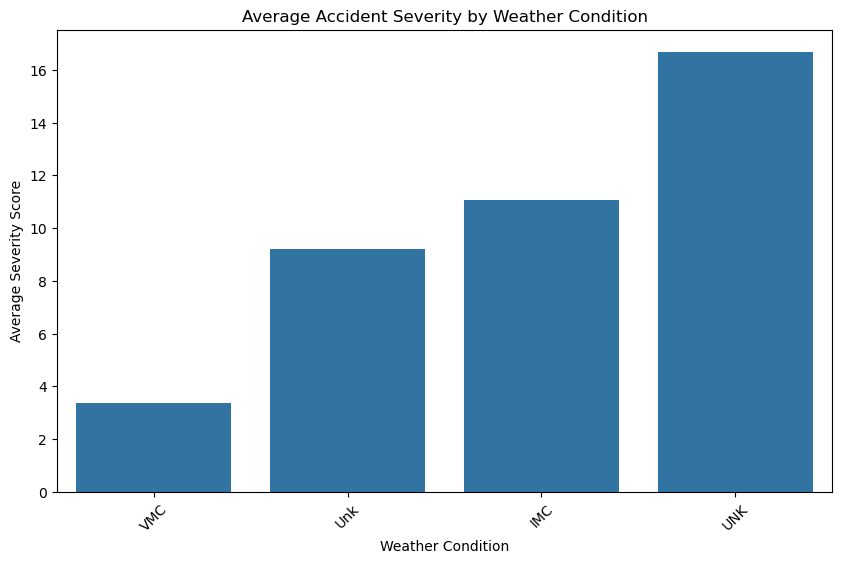

In [581]:
weather_condition = (
    my_data
    .groupby('Weather.Condition')['weight_sev_score']
    .mean()
    .reset_index()
    .sort_values('weight_sev_score')
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=weather_condition,
    x='Weather.Condition',
    y='weight_sev_score'
)

plt.title('Average Accident Severity by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Severity Score')

plt.xticks(rotation=45)

plt.show()


Weather Condition has influence on the severity of aircraft accidents. 

This barplot shows the relation between weather and the mean severity score.It shows the most convenient

 to the least convenient weather condition for aircraft operations. 

## Conclusion

Following the analysis of the aviation accident dataset, weather condition, extent of aircraft damage and 

aircraft make were seen to be strong determinants of safe aircraft operations(operational risk)

The findings of this analysis are a sufficient guide to the head of aviation division in making a 

decision in flight acquisition for both commercial and private  operations.

In [582]:
my_data.to_csv("aviation_final", index=False) # converting the cleaned dataset into a csv file

In [583]:
my_data.to_csv(r"C:\Users\Hp\Downloads\aviation_final.csv", index=False) # storing the cleaned dataset into the downloads folder
